# Integrating Multi-Source Spatial Variability: Rook, Queen, Laplacian, CNN, and GWRK

This notebook explains and demonstrates a conceptual-to-practical framework for modeling **multi-source spatial variability** in agricultural fields.
It progresses from simple neighborhood operators (Rook and Queen) to graph Laplacians, semivariance, Kriging, and GWRK, and treats/models spatial coordinates explicitly.


## 1. Hypothesis
Spatial neighborhood structure contains information about **underlying spatial variability** in measured attributes (e.g., yield). Nearby cells tend to exhibit similar values because of shared environmental or management effects.

## 2. Neighborhood Representation: Rook and Queen
- **Rook adjacency:** Considers N, S, E, W neighbors.
- **Queen adjacency:** Considers all 8 neighbors.

These stencils are simple binary approximations of how local information propagates spatially.

## 3. Weighted Neighborhoods and the Laplacian
Instead of binary adjacency, assign **continuous weights** that decay with distance:

$$w_{ij} = \exp\left(-\frac{d_{ij}^2}{2h^2}\right)$$

The **graph Laplacian**:
$$L = D - W$$
quantifies how much each cell deviates from its weighted neighbors. Its energy term:
$$y^T L y = \frac{1}{2}\sum_{i,j} w_{ij}(y_i - y_j)^2$$
measures local roughness, analogous to **semivariance** in geostatistics.

## 4. From Laplacian to Semivariance and GWRK
- **Semivariance:** Empirically measures dissimilarity as a function of lag distance.
- **Kriging:** Uses covariance functions to predict spatially correlated residuals.
- **GWR:** Allows regression coefficients to vary smoothly with coordinates.
- **GWRK:** Combines both—local regression (GWR) and global covariance (Kriging).

## 5. Multi-Source Spatial Variability Model
We simulate yield as the sum of multiple processes:
$$y(x,y) = y_{trend}(x,y) + y_{management}(x,y) + y_{soil}(x,y) + \epsilon(x,y)$$
Each term corresponds to a distinct spatial scale: trend (broad), management (fine), soil (mesoscale), noise (micro).

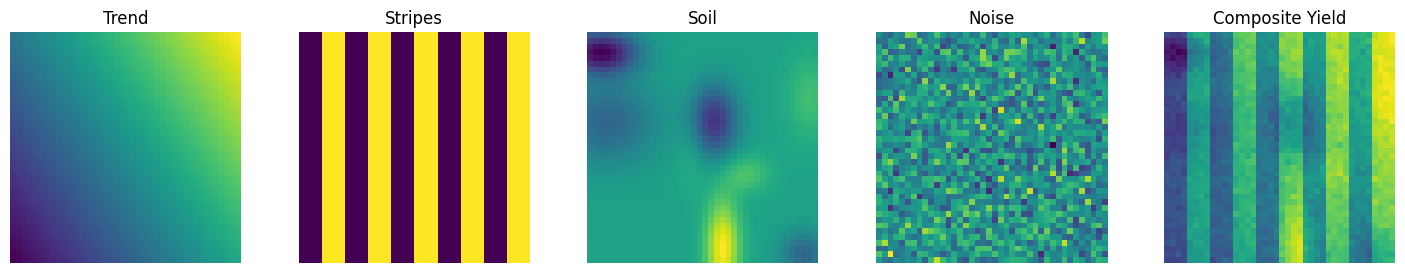

In [1]:
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from scipy.spatial.distance import cdist
from scipy.signal import convolve2d
np.random.seed(42)

nr, nc = 40, 40
x, y = np.meshgrid(np.arange(nc), np.arange(nr))
coords = np.column_stack([x.ravel(), y.ravel()])

# Field components
y_trend = 0.6*(x/x.max()) + 0.4*(y/y.max())
stripe_w = 4
y_stripe = ((x // stripe_w) % 2).astype(float) - 0.5

def gaussian_blob(cx, cy, sx, sy, amp):
    return amp*np.exp(-(((x-cx)**2)/(2*sx**2)+((y-cy)**2)/(2*sy**2)))

y_soil = sum(gaussian_blob(np.random.randint(0,nc), np.random.randint(0,nr),
                           np.random.uniform(2,6), np.random.uniform(2,6),
                           np.random.uniform(-1,1)) for _ in range(8))

y_noise = np.random.normal(0,0.05,(nr,nc))
yield_field = 2.0 + 0.9*y_trend + 0.6*y_stripe + 0.8*y_soil + y_noise

fig, axs = plt.subplots(1,5,figsize=(18,3))
for ax,im,title in zip(axs,[y_trend,y_stripe,y_soil,y_noise,yield_field],
                       ["Trend","Stripes","Soil","Noise","Composite Yield"]):
    ax.imshow(im,origin='lower',cmap='viridis'); ax.set_title(title); ax.axis('off')
plt.show()

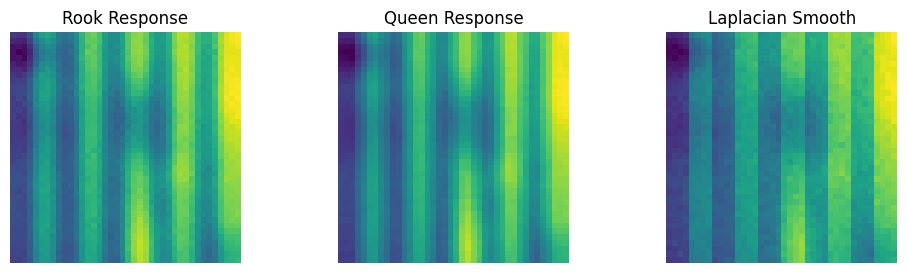

In [2]:
# Rook and Queen kernels
rook = np.array([[0,1,0],[1,0,1],[0,1,0]],float); rook/=rook.sum()
queen = np.ones((3,3),float); queen[1,1]=0; queen/=queen.sum()

def conv2(img, kernel):
    return convolve2d(img, kernel[::-1,::-1], mode='same', boundary='symm')

resp_rook = conv2(yield_field, rook)
resp_queen = conv2(yield_field, queen)

# Laplacian smoother
dist = cdist(coords, coords)
h = 3.0
W = np.exp(-dist**2/(2*h**2))
np.fill_diagonal(W, 0)
D = np.diag(W.sum(axis=1))
L = D - W
lam = 1.0
y_vec = yield_field.ravel()
M = D + lam*L
y_smooth = np.linalg.solve(M, D@y_vec).reshape(nr,nc)

fig, axs = plt.subplots(1,3,figsize=(12,3))
for ax,im,title in zip(axs,[resp_rook,resp_queen,y_smooth],
                       ["Rook Response","Queen Response","Laplacian Smooth"]):
    ax.imshow(im,origin='lower',cmap='viridis'); ax.set_title(title); ax.axis('off')
plt.show()

In [3]:
# Variance explained
def variance_explained(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res/ss_tot

res = pd.DataFrame({
    'Model':['Rook','Queen','Laplacian'],
    'R2':[variance_explained(yield_field,resp_rook),
          variance_explained(yield_field,resp_queen),
          variance_explained(yield_field,y_smooth)]
})
res

,Model,R2
0,Rook,0.931142
1,Queen,0.866233
2,Laplacian,0.880050


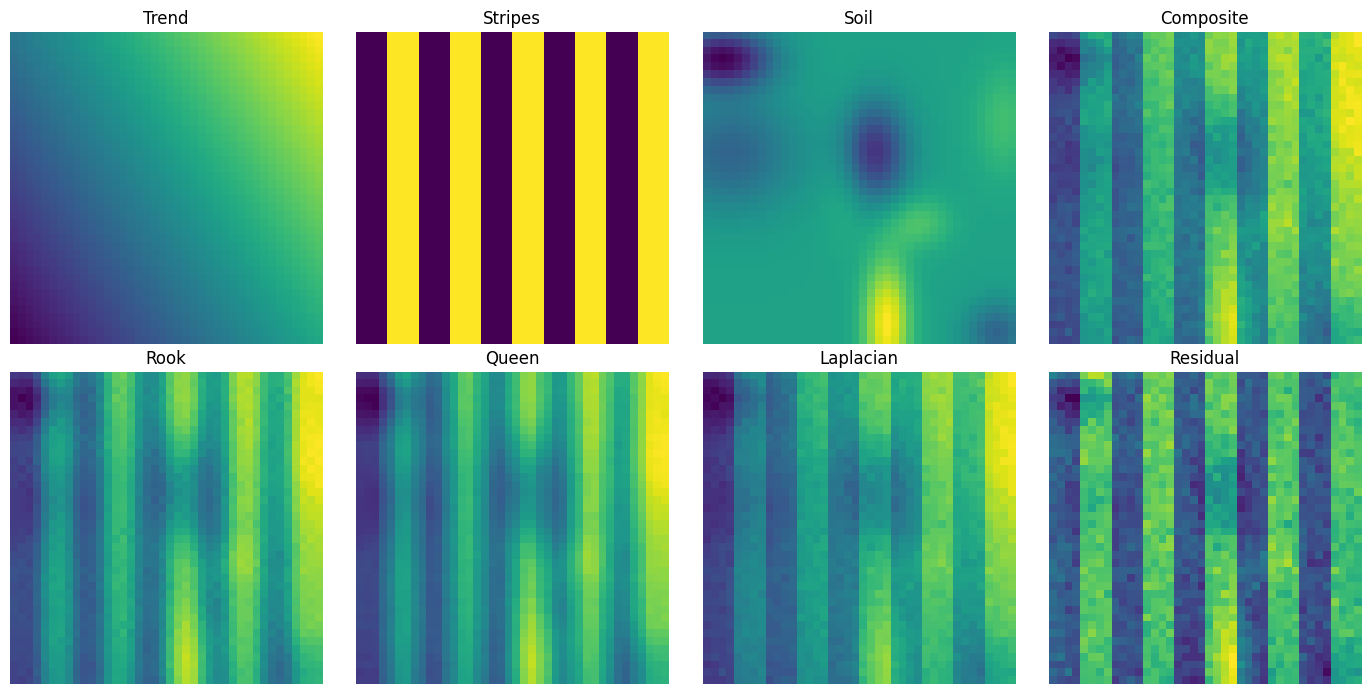

In [4]:
# Visualization Panels: Decomposition vs Model Outputs
fig, axs = plt.subplots(2,4,figsize=(14,7))
fields = [y_trend,y_stripe,y_soil,yield_field,resp_rook,resp_queen,y_smooth,yield_field-y_smooth]
titles = ["Trend","Stripes","Soil","Composite","Rook","Queen","Laplacian","Residual"]
for ax,im,title in zip(axs.ravel(),fields,titles):
    ax.imshow(im,origin='lower',cmap='viridis'); ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()

## 9. Interpretation
- **Rook filter** captures directional fine-scale variation (stripes).
- **Queen filter** captures isotropic soil variation.
- **Laplacian smoother** captures broad-scale trend and mesoscale soil structure.
- **CNN** or **GWRK** would combine these effects adaptively, learning both local weighting (Laplacian-like) and global covariance (Kriging-like) effects.